# 02 - FaceNet512 Optimized Training

Improve FaceNet512 models to outperform FaceNet128 via:
- **Feature engineering**: |e1-e2| + e1*e2 (concatenated)
- **Wider/deeper MLP**: 1024→512→256→1 with L2 regularization
- **Hyperparameter tuning**: compare multiple architectures
- **Learning rate scheduling**: ReduceLROnPlateau

Results saved to `logs/my_logs/Facenet512_*_improved/`

In [1]:
import os, pickle, time, itertools
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

print('TensorFlow:', tf.__version__)
print('Keras:', keras.__version__)

TensorFlow: 2.20.0
Keras: 3.12.0


In [2]:
NOTEBOOK_DIR = os.path.dirname(os.path.abspath("__file__")) if "__file__" in dir() else os.getcwd()
PROJECT_ROOT = os.path.abspath(os.path.join(NOTEBOOK_DIR, '..'))
if not os.path.exists(os.path.join(PROJECT_ROOT, 'notebooks')):
    PROJECT_ROOT = os.getcwd()

PKL_DIR     = os.path.join(PROJECT_ROOT, 'models', 'precomputed')
DATASET_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw', 'lfw_funneled')
PAIRS_FILE  = os.path.join(DATASET_DIR, 'pairs.txt')
OUTPUT_DIR  = os.path.join(PROJECT_ROOT, 'logs', 'my_logs')
os.makedirs(OUTPUT_DIR, exist_ok=True)

print('PROJECT_ROOT:', PROJECT_ROOT)
print('PKL_DIR:', PKL_DIR)

PROJECT_ROOT: x:\sv3_hk2\graduation_thesis\facenet
PKL_DIR: x:\sv3_hk2\graduation_thesis\facenet\models\precomputed


In [3]:
def load_pairs(pf, dd):
    pairs = []
    with open(pf) as f: lines = f.read().strip().splitlines()
    nf, np_ = int(lines[0].split()[0]), int(lines[0].split()[1])
    idx = 1
    for _ in range(nf):
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            nm,i,j = p[0],int(p[1]),int(p[2])
            p1=os.path.join(dd,nm,f'{nm}_{i:04d}.jpg')
            p2=os.path.join(dd,nm,f'{nm}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,1))
        for _ in range(np_):
            p = lines[idx].split(); idx += 1
            n1,i,n2,j = p[0],int(p[1]),p[2],int(p[3])
            p1=os.path.join(dd,n1,f'{n1}_{i:04d}.jpg')
            p2=os.path.join(dd,n2,f'{n2}_{j:04d}.jpg')
            if os.path.exists(p1) and os.path.exists(p2): pairs.append((p1,p2,0))
    sm=sum(l==1 for _,_,l in pairs)
    print(f'{len(pairs)} pairs (same={sm}, diff={len(pairs)-sm})')
    return pairs

def load_pkl_remap(pkl_path, new_base):
    with open(pkl_path,'rb') as f: raw = pickle.load(f)
    remapped = {}
    for k, v in raw.items():
        k_norm = k.replace("\\", "/")
        if "lfw_funneled/" in k_norm:
            rel = k_norm.split("lfw_funneled/",1)[1]
            new_key = os.path.normpath(os.path.join(new_base, rel))
        else:
            new_key = k
        remapped[new_key] = np.array(v)
    print(f'Loaded {len(remapped)} from {os.path.basename(pkl_path)}')
    return remapped

In [4]:
# ---- Feature Engineering Strategies ----

def build_features_absdiff(pairs, emb_dict):
    """Baseline: |e1-e2| only."""
    X, y = [], []
    for p1,p2,lbl in pairs:
        e1,e2 = emb_dict.get(p1), emb_dict.get(p2)
        if e1 is None or e2 is None: continue
        if np.sum(e1)==0 or np.sum(e2)==0: continue
        X.append(np.abs(e1-e2)); y.append(lbl)
    return np.array(X), np.array(y)

def build_features_concat(pairs, emb_dict):
    """Concatenate |e1-e2| and e1*e2 (recommended)."""
    X, y = [], []
    for p1,p2,lbl in pairs:
        e1,e2 = emb_dict.get(p1), emb_dict.get(p2)
        if e1 is None or e2 is None: continue
        if np.sum(e1)==0 or np.sum(e2)==0: continue
        X.append(np.concatenate([np.abs(e1-e2), e1*e2])); y.append(lbl)
    return np.array(X), np.array(y)

def build_features_squared(pairs, emb_dict):
    """Concat |e1-e2| + e1*e2 + (e1-e2)^2."""
    X, y = [], []
    for p1,p2,lbl in pairs:
        e1,e2 = emb_dict.get(p1), emb_dict.get(p2)
        if e1 is None or e2 is None: continue
        if np.sum(e1)==0 or np.sum(e2)==0: continue
        diff = e1 - e2
        X.append(np.concatenate([np.abs(diff), e1*e2, diff**2])); y.append(lbl)
    return np.array(X), np.array(y)

In [5]:
# ---- MLP Architecture Variants ----

def build_mlp_v1(dim):
    """Extra-wide: 2048->1024->512->1."""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(2048, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_mlp_v2(dim):
    """Medium-wide: 1024->512->256->1 (recommended)."""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.3),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_mlp_v3(dim):
    """Deep: 1024->512->256->128->1."""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(1024, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.5),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(128, activation='relu'), layers.Dropout(0.2),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

def build_mlp_v4(dim):
    """Narrower but deeper: 512->256->128->64->1."""
    m = keras.Sequential([
        layers.Input(shape=(dim,)),
        layers.Dense(512, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.4),
        layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.BatchNormalization(), layers.Dropout(0.3),
        layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
        layers.Dropout(0.2),
        layers.Dense(64, activation='relu'), layers.Dropout(0.1),
        layers.Dense(1, activation='sigmoid')
    ])
    m.compile(optimizer=keras.optimizers.Adam(5e-4), loss='binary_crossentropy', metrics=['accuracy'])
    return m

In [6]:
def compute_eer(yt, ys):
    ths=np.linspace(0,1,500); fl,rl=[],[]
    for t in ths:
        yp=(ys>=t).astype(int)
        fp=np.sum((yp==1)&(yt==0)); tn=np.sum((yp==0)&(yt==0))
        fn=np.sum((yp==0)&(yt==1)); tp=np.sum((yp==1)&(yt==1))
        fl.append(fp/(fp+tn+1e-9)); rl.append(fn/(fn+tp+1e-9))
    far,frr=np.array(fl),np.array(rl)
    idx=np.argmin(np.abs(far-frr))
    return (far[idx]+frr[idx])/2, ths[idx]

def plot_confusion_matrix(y_true, y_pred, classes, output_path, normalize=True):
    from sklearn.metrics import confusion_matrix
    cm = confusion_matrix(y_true, y_pred)
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.figure(figsize=(7, 6))
    plt.imshow(cm, interpolation='nearest')
    plt.title('Confusion Matrix', fontsize=14)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            value = cm[i, j]
            text = f"{value:.2f}" if normalize else f"{int(value)}"
            plt.text(j, i, text, ha="center", va="center",
                     color="white" if value > cm.max()/2 else "black",
                     fontsize=10, fontweight='bold')
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f"{output_path}/confusion_matrix.png", dpi=150)
    plt.show()
    plt.close()

def visualize_results(hist, tag, output_path):
    epochs = range(1, len(hist.history['accuracy']) + 1)
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, (m, title), (c1, c2) in zip(axes,
        [('accuracy', 'Accuracy'), ('loss', 'Loss')],
        [('blue','red'), ('green','purple')]):
        train_v = hist.history[m]
        val_v = hist.history[f'val_{m}']
        ax.plot(epochs, train_v, 'o-', color=c1, label=f'Training {title}', linewidth=2, markersize=6)
        ax.plot(epochs, val_v, 's-', color=c2, label=f'Validation {title}', linewidth=2, markersize=6)
        ax.set_title(f'{tag} — {title}', fontsize=14)
        ax.set_xlabel('Epochs')
        ax.legend()
        ax.grid(True, linestyle='--', alpha=0.3)
    plt.tight_layout()
    plt.savefig(os.path.join(output_path, 'training_curves.png'), dpi=150)
    plt.show()
    plt.close()

In [7]:
def evaluate_and_save(mlp, Xte, yte, Xtr, ytr, hist, tag, od, detector, epochs=24):
    os.makedirs(od, exist_ok=True)
    t0=time.time(); ys=mlp.predict(Xte,verbose=0).flatten(); tit=time.time()-t0
    yp=(ys>=0.5).astype(int)
    trl,tra=mlp.evaluate(Xtr,ytr,verbose=0)
    tel,tea=mlp.evaluate(Xte,yte,verbose=0)
    prec=precision_score(yte,yp,zero_division=0)
    rec=recall_score(yte,yp,zero_division=0)
    f1v=f1_score(yte,yp,zero_division=0)
    eer, eer_t = compute_eer(yte, ys)
    infer_avg_s = tit / len(Xte)

    visualize_results(hist, tag, od)
    plot_confusion_matrix(yte, yp, classes=['different', 'same'], output_path=od)

    report = classification_report(yte, yp, target_names=['different', 'same'], zero_division=0)
    print('\n--- CLASSIFICATION REPORT ---\n', report)
    with open(os.path.join(od, 'classification_report.txt'), 'w') as f: f.write(report)

    rpt = f"--- BAO CAO KET QUA NHAN DIEN (IMPROVED) ---\nModel: {tag} | Detector: {detector}\n"
    rpt += f"EER: {eer:.4f} @ Threshold: {eer_t:.4f}\nTrain Acc: {tra:.4f}\nTest Acc: {tea:.4f}\n"
    rpt += f"Train Loss: {trl:.4f}\nTest Loss: {tel:.4f}\nPrecision: {prec:.4f}\nRecall: {rec:.4f}\nF1: {f1v:.4f}\n"
    rpt += f"TB predict/anh: {infer_avg_s:.4f}s\n"
    print(rpt)
    with open(os.path.join(od, 'final_report.txt'), 'w', encoding='utf-8') as f: f.write(rpt)

    return {'model': tag, 'train_acc': round(tra,4), 'test_acc': round(tea,4),
            'precision': round(prec,4), 'recall': round(rec,4), 'f1': round(f1v,4),
            'eer': round(eer,4), 'threshold': round(float(eer_t),4),
            'train_loss': round(trl,4), 'test_loss': round(tel,4),
            'infer_avg_s': round(infer_avg_s,6)}

In [8]:
pairs = load_pairs(PAIRS_FILE, DATASET_DIR)
all_results = []
print('Ready!')

5996 pairs (same=2998, diff=2998)
Ready!


---
## Hyperparameter Search
Tìm feature engineering + MLP architecture tốt nhất cho FaceNet512.

In [9]:
build_features_map = {
    'absdiff': build_features_absdiff,
    'concat': build_features_concat,
    'squared': build_features_squared,
}

build_mlp_map = {
    'MLP_v1': build_mlp_v1,
    'MLP_v2': build_mlp_v2,
    'MLP_v3': build_mlp_v3,
    'MLP_v4': build_mlp_v4,
}

pkl_model_groups = [
    ('Facenet512', 'mtcnn', 'Facenet512_mtcnn_embeddings.pkl'),
    ('Facenet512', 'retinaface', 'Facenet512_retinaface_embeddings.pkl'),
]

N_TRIAL_EPOCHS = 8  # quick trial epochs for comparison

trial_results = []
for model_name, detector, pkl_file in pkl_model_groups:
    pkl_path = os.path.join(PKL_DIR, pkl_file)
    emb_dict = load_pkl_remap(pkl_path, DATASET_DIR)

    for feat_name, build_feat in build_features_map.items():
        X, y = build_feat(pairs, emb_dict)
        Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
        dim = Xtr.shape[1]

        for mlp_name, build_mlp_fn in build_mlp_map.items():
            tag_trial = f'{model_name}_{detector}_{feat_name}_{mlp_name}'
            print(f'\n--- TRIAL: {tag_trial} (dim={dim}) ---')
            mlp = build_mlp_fn(dim)
            cb = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            lr = keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=0)
            hist = mlp.fit(Xtr,ytr,epochs=N_TRIAL_EPOCHS,batch_size=64,
                          validation_split=0.15,callbacks=[cb,lr],verbose=0)
            ys = mlp.predict(Xte,verbose=0).flatten()
            yp = (ys>=0.5).astype(int)
            tel,tea = mlp.evaluate(Xte,yte,verbose=0)
            f1v = f1_score(yte,yp,zero_division=0)
            eer, _ = compute_eer(yte, ys)
            trial_results.append({'tag': tag_trial, 'dim': dim, 'feat': feat_name,
                                  'mlp': mlp_name, 'test_acc': round(tea,4),
                                  'f1': round(f1v,4), 'eer': round(eer,4)})
            print(f'  Test Acc: {tea:.4f}, F1: {f1v:.4f}, EER: {eer:.4f}')
            tf.keras.backend.clear_session()

Loaded 7701 from Facenet512_mtcnn_embeddings.pkl

--- TRIAL: Facenet512_mtcnn_absdiff_MLP_v1 (dim=512) ---
  Test Acc: 0.9367, F1: 0.9349, EER: 0.0667


--- TRIAL: Facenet512_mtcnn_absdiff_MLP_v2 (dim=512) ---
  Test Acc: 0.9417, F1: 0.9416, EER: 0.0583

--- TRIAL: Facenet512_mtcnn_absdiff_MLP_v3 (dim=512) ---
  Test Acc: 0.9417, F1: 0.9403, EER: 0.0608

--- TRIAL: Facenet512_mtcnn_absdiff_MLP_v4 (dim=512) ---
  Test Acc: 0.9417, F1: 0.9401, EER: 0.0608

--- TRIAL: Facenet512_mtcnn_concat_MLP_v1 (dim=1024) ---
  Test Acc: 0.9475, F1: 0.9453, EER: 0.0575

--- TRIAL: Facenet512_mtcnn_concat_MLP_v2 (dim=1024) ---
  Test Acc: 0.9425, F1: 0.9397, EER: 0.0608

--- TRIAL: Facenet512_mtcnn_concat_MLP_v3 (dim=1024) ---
  Test Acc: 0.9492, F1: 0.9480, EER: 0.0550

--- TRIAL: Facenet512_mtcnn_concat_MLP_v4 (dim=1024) ---
  Test Acc: 0.9533, F1: 0.9519, EER: 0.0567

--- TRIAL: Facenet512_mtcnn_squared_MLP_v1 (dim=1536) ---
  Test Acc: 0.9492, F1: 0.9486, EER: 0.0517

--- TRIAL: Facenet512_mtcnn_sq

In [10]:
df_trials = pd.DataFrame(trial_results)
print('\n========== HYPERPARAMETER TRIAL RESULTS ==========')
print(df_trials.to_string(index=False))

# Find best for each detector
for detector in ['mtcnn', 'retinaface']:
    sub = df_trials[df_trials['tag'].str.contains(detector)]
    if len(sub) == 0: continue
    best_acc = sub.loc[sub['test_acc'].idxmax()]
    best_f1 = sub.loc[sub['f1'].idxmax()]
    best_eer = sub.loc[sub['eer'].idxmin()]
    print(f'\n--- Best for {detector} ---')
    print(f'By Test Acc: {best_acc["tag"]} ({best_acc["test_acc"]})')
    print(f'By F1:       {best_f1["tag"]} ({best_f1["f1"]})')
    print(f'By EER:      {best_eer["tag"]} ({best_eer["eer"]})')


========== HYPERPARAMETER TRIAL RESULTS ==========
                                 tag  dim    feat    mlp  test_acc     f1    eer
     Facenet512_mtcnn_absdiff_MLP_v1  512 absdiff MLP_v1    0.9367 0.9349 0.0667
     Facenet512_mtcnn_absdiff_MLP_v2  512 absdiff MLP_v2    0.9417 0.9416 0.0583
     Facenet512_mtcnn_absdiff_MLP_v3  512 absdiff MLP_v3    0.9417 0.9403 0.0608
     Facenet512_mtcnn_absdiff_MLP_v4  512 absdiff MLP_v4    0.9417 0.9401 0.0608
      Facenet512_mtcnn_concat_MLP_v1 1024  concat MLP_v1    0.9475 0.9453 0.0575
      Facenet512_mtcnn_concat_MLP_v2 1024  concat MLP_v2    0.9425 0.9397 0.0608
      Facenet512_mtcnn_concat_MLP_v3 1024  concat MLP_v3    0.9492 0.9480 0.0550
      Facenet512_mtcnn_concat_MLP_v4 1024  concat MLP_v4    0.9533 0.9519 0.0567
     Facenet512_mtcnn_squared_MLP_v1 1536 squared MLP_v1    0.9492 0.9486 0.0517
     Facenet512_mtcnn_squared_MLP_v2 1536 squared MLP_v2    0.9467 0.9450 0.0633
     Facenet512_mtcnn_squared_MLP_v3 1536 squared MLP_v3 

---
## Train Best Configurations (Full Epochs)

In [11]:
# Select best combos from trials
BEST_CONFIGS = [
    # (model_name, detector, pkl_file, feat_name, mlp_name, build_feat_fn, build_mlp_fn)
]

for detector in ['mtcnn', 'retinaface']:
    sub = df_trials[df_trials['tag'].str.contains(detector)]
    if len(sub) == 0: continue
    best_row = sub.loc[sub['test_acc'].idxmax()]
    feat = best_row['feat']
    mlp = best_row['mlp']
    pkl_file = f'Facenet512_{detector}_embeddings.pkl'
    BEST_CONFIGS.append(('Facenet512', detector, pkl_file, feat, mlp,
                         build_features_map[feat], build_mlp_map[mlp]))

print(f'Best configs found: {len(BEST_CONFIGS)}')
for c in BEST_CONFIGS:
    print(f'  {c[0]}_{c[1]} -> feat={c[3]}, mlp={c[4]}')

Best configs found: 2
  Facenet512_mtcnn -> feat=concat, mlp=MLP_v4
  Facenet512_retinaface -> feat=concat, mlp=MLP_v1



 FULL TRAIN: Facenet512_mtcnn_concat_MLP_v4
Loaded 7701 from Facenet512_mtcnn_embeddings.pkl
Features: (5996, 1024)
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 29ms/step - accuracy: 0.9006 - loss: 0.3791 - val_accuracy: 0.9139 - val_loss: 0.4207 - learning_rate: 5.0000e-04
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9431 - loss: 0.2819 - val_accuracy: 0.9167 - val_loss: 0.3877 - learning_rate: 5.0000e-04
Epoch 3/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9549 - loss: 0.2487 - val_accuracy: 0.9306 - val_loss: 0.3927 - learning_rate: 5.0000e-04
Epoch 4/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9585 - loss: 0.2320 - val_accuracy: 0.9264 - val_loss: 0.4277 - learning_rate: 5.0000e-04
Epoch 5/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.9684 - loss: 0.2054 - val_accuracy: 0.9306 - val_loss: 0.3816 - learning_rate: 5.0000e-04
Epoch 6/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9701 - loss: 0.1911 - val_accuracy: 0.9306 

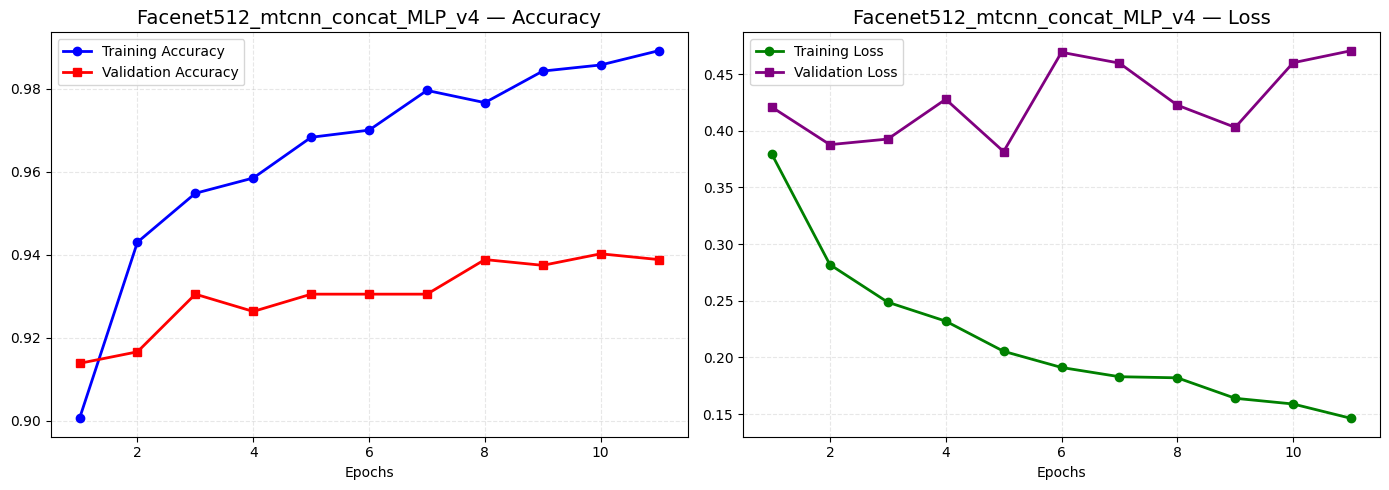

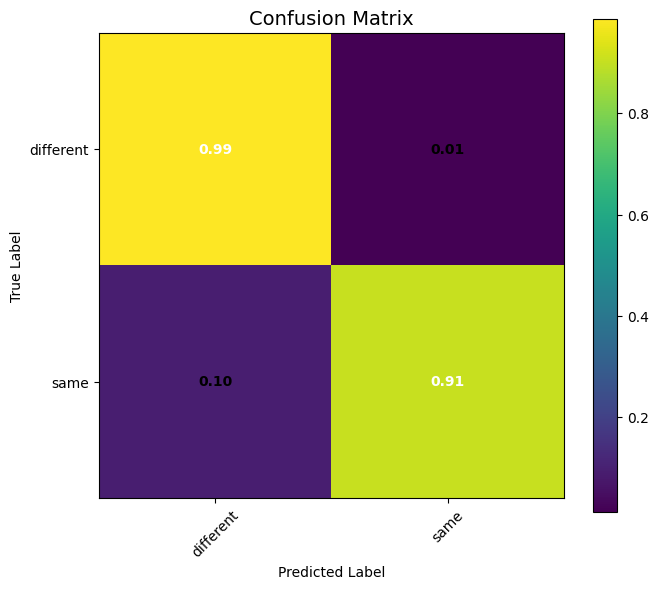


--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

   different       0.91      0.99      0.95       600
        same       0.99      0.91      0.94       600

    accuracy                           0.95      1200
   macro avg       0.95      0.95      0.95      1200
weighted avg       0.95      0.95      0.95      1200

--- BAO CAO KET QUA NHAN DIEN (IMPROVED) ---
Model: Facenet512_mtcnn_concat_MLP_v4 | Detector: mtcnn
EER: 0.0617 @ Threshold: 0.0942
Train Acc: 0.9704
Test Acc: 0.9458
Train Loss: 0.1978
Test Loss: 0.3256
Precision: 0.9855
Recall: 0.9050
F1: 0.9435
TB predict/anh: 0.0003s


 FULL TRAIN: Facenet512_retinaface_concat_MLP_v1
Loaded 7701 from Facenet512_retinaface_embeddings.pkl
Features: (5996, 1024)
Epoch 1/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 12s 110ms/step - accuracy: 0.9411 - loss: 0.5244 - val_accuracy: 0.9014 - val_loss: 0.7991 - learning_rate: 5.0000e-04
Epoch 2/30
64/64 ━━━━━━━━━━━━━━━━━━━━ 7s 113ms/step - accuracy: 0.9657 - loss: 0.44

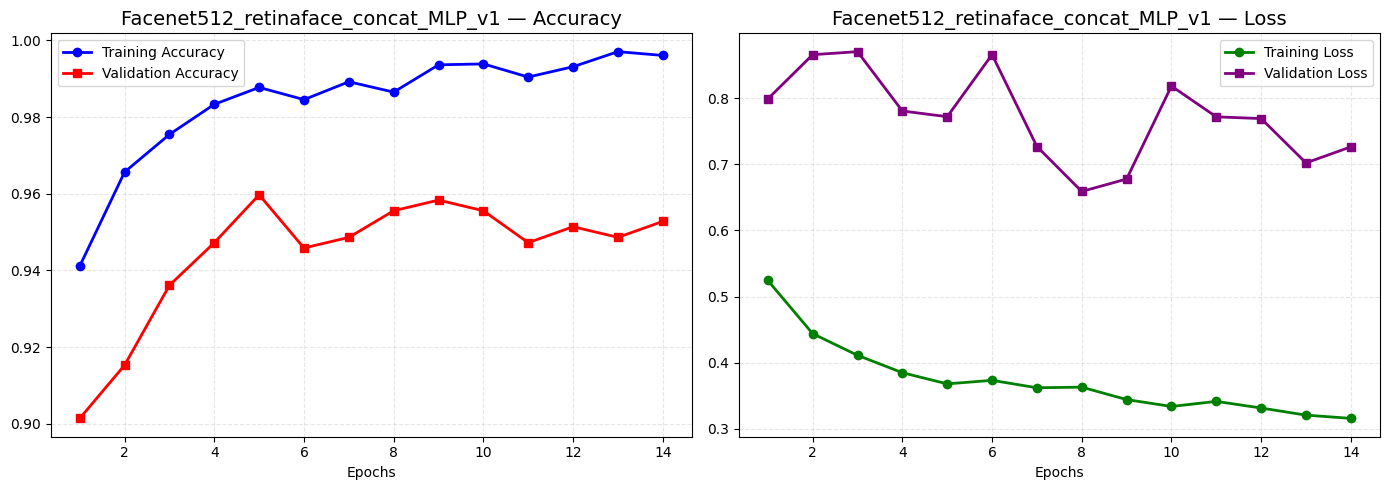

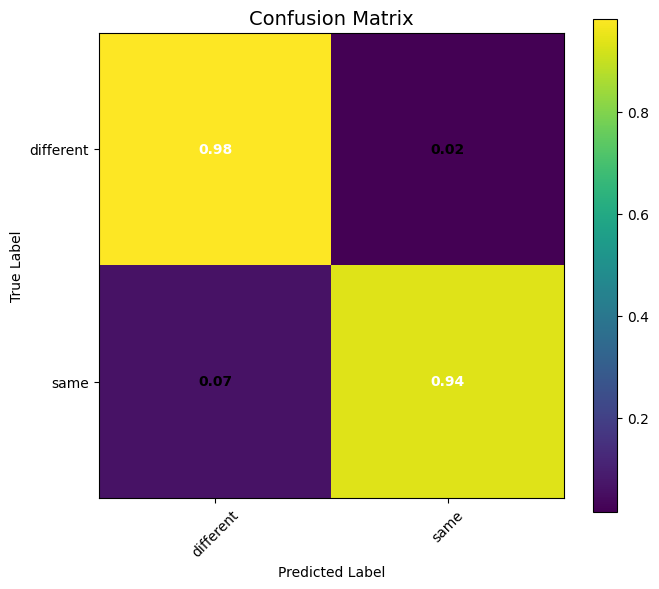


--- CLASSIFICATION REPORT ---
               precision    recall  f1-score   support

   different       0.94      0.98      0.96       600
        same       0.98      0.94      0.96       600

    accuracy                           0.96      1200
   macro avg       0.96      0.96      0.96      1200
weighted avg       0.96      0.96      0.96      1200

--- BAO CAO KET QUA NHAN DIEN (IMPROVED) ---
Model: Facenet512_retinaface_concat_MLP_v1 | Detector: retinaface
EER: 0.0508 @ Threshold: 0.0401
Train Acc: 0.9915
Test Acc: 0.9592
Train Loss: 0.3799
Test Loss: 0.6117
Precision: 0.9825
Recall: 0.9350
F1: 0.9582
TB predict/anh: 0.0004s



In [12]:
EPOCHS_FULL = 30

for model_name, detector, pkl_file, feat_name, mlp_name, build_feat_fn, build_mlp_fn in BEST_CONFIGS:
    tag = f'{model_name}_{detector}_{feat_name}_{mlp_name}'
    od  = os.path.join(OUTPUT_DIR, tag)
    pkl_path = os.path.join(PKL_DIR, pkl_file)

    print(f'\n{"="*60}\n FULL TRAIN: {tag}\n{"="*60}')

    emb_dict = load_pkl_remap(pkl_path, DATASET_DIR)
    X, y = build_feat_fn(pairs, emb_dict)
    print(f'Features: {X.shape}')
    Xtr,Xte,ytr,yte = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

    mlp = build_mlp_fn(Xtr.shape[1])
    callbacks = [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
    ]
    hist = mlp.fit(Xtr,ytr,epochs=EPOCHS_FULL,batch_size=64,
                   validation_split=0.15,callbacks=callbacks,verbose=1)

    result = evaluate_and_save(mlp, Xte, yte, Xtr, ytr, hist, tag, od, detector, epochs=EPOCHS_FULL)
    all_results.append(result)
    tf.keras.backend.clear_session()

---
## Final Comparison (All Models)

In [13]:
df_final = pd.DataFrame(all_results)
print('\n========== FINAL COMPARISON (ALL IMPROVED MODELS) ==========')
print(df_final.to_string(index=False))

csv_path = os.path.join(OUTPUT_DIR, 'MLP_Facenet512_Improved_Metrics.csv')
df_final.to_csv(csv_path, index=False)
print(f'\nSaved to: {csv_path}')


========== FINAL COMPARISON (ALL IMPROVED MODELS) ==========
                              model  train_acc  test_acc  precision  recall     f1    eer  threshold  train_loss  test_loss  infer_avg_s
     Facenet512_mtcnn_concat_MLP_v4     0.9704    0.9458     0.9855   0.905 0.9435 0.0617     0.0942      0.1978     0.3256     0.000341
Facenet512_retinaface_concat_MLP_v1     0.9915    0.9592     0.9825   0.935 0.9582 0.0508     0.0401      0.3799     0.6117     0.000440

Saved to: x:\sv3_hk2\graduation_thesis\facenet\logs\my_logs\MLP_Facenet512_Improved_Metrics.csv


In [14]:
print('\n=== BEST IMPROVED MODEL PER METRIC ===')
for metric in ['test_acc', 'f1', 'precision', 'recall']:
    best = df_final.loc[df_final[metric].idxmax()]
    print(f'{metric}: {best["model"]} ({best[metric]:.4f})')
for metric in ['eer', 'test_loss']:
    best = df_final.loc[df_final[metric].idxmin()]
    print(f'{metric} (lower): {best["model"]} ({best[metric]:.4f})')

print(f'\n\n=== Comparison with FaceNet128 (baseline) ===')
print('Facenet_retinaface baseline: Test Acc=0.9408, F1=0.9407, EER=0.0567')
if len(df_final) > 0:
    best_overall = df_final.loc[df_final['test_acc'].idxmax()]
    print(f'Best improved: {best_overall["model"]} -> Test Acc={best_overall["test_acc"]}, F1={best_overall["f1"]}, EER={best_overall["eer"]}')
    if best_overall['test_acc'] > 0.9408:
        print('>>> FaceNet512 IMPROVED vượt FaceNet128! <<<')


=== BEST IMPROVED MODEL PER METRIC ===
test_acc: Facenet512_retinaface_concat_MLP_v1 (0.9592)
f1: Facenet512_retinaface_concat_MLP_v1 (0.9582)
precision: Facenet512_mtcnn_concat_MLP_v4 (0.9855)
recall: Facenet512_retinaface_concat_MLP_v1 (0.9350)
eer (lower): Facenet512_retinaface_concat_MLP_v1 (0.0508)
test_loss (lower): Facenet512_mtcnn_concat_MLP_v4 (0.3256)


=== Comparison with FaceNet128 (baseline) ===
Facenet_retinaface baseline: Test Acc=0.9408, F1=0.9407, EER=0.0567
Best improved: Facenet512_retinaface_concat_MLP_v1 -> Test Acc=0.9592, F1=0.9582, EER=0.0508
>>> FaceNet512 IMPROVED vượt FaceNet128! <<<


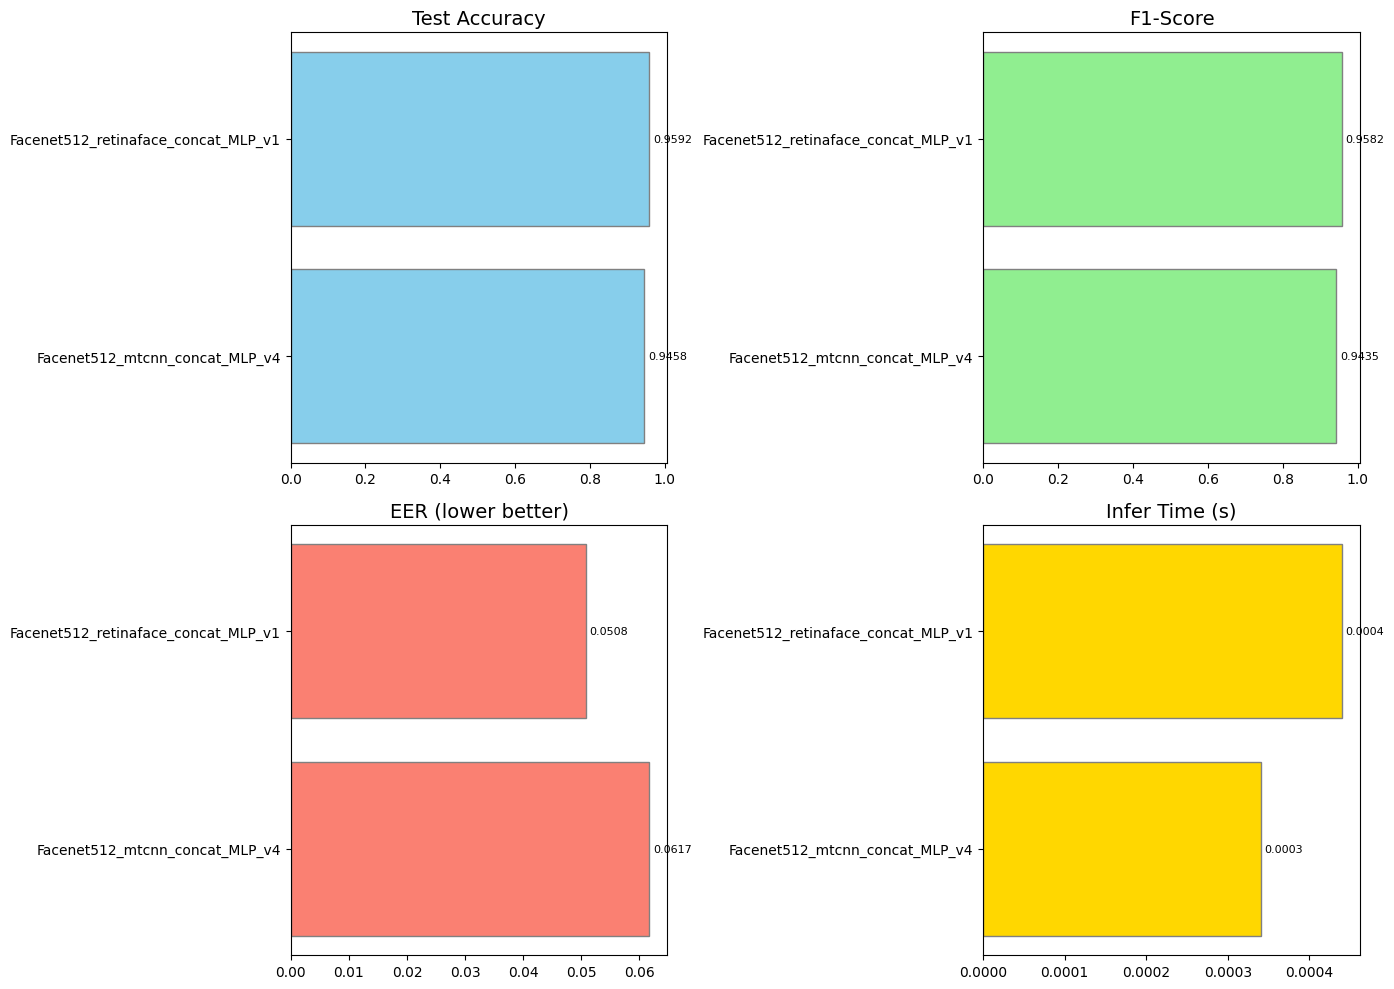

Done!


In [15]:
# Plot final comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()
metrics = [('test_acc', 'Test Accuracy'), ('f1', 'F1-Score'), ('eer', 'EER (lower better)'), ('infer_avg_s', 'Infer Time (s)')]
colors = ['skyblue', 'lightgreen', 'salmon', 'gold']
for ax, (metric, title), color in zip(axes, metrics, colors):
    vals = df_final[metric]
    bars = ax.barh(df_final['model'], vals, color=color, edgecolor='gray')
    ax.set_title(title, fontsize=14)
    for bar, v in zip(bars, vals):
        ax.text(bar.get_width() + max(vals)*0.01, bar.get_y() + bar.get_height()/2,
                f'{v:.4f}', va='center', fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'comparison_facenet512_improved.png'), dpi=150, bbox_inches='tight')
plt.show()
plt.close()
print('Done!')